# InsightX — Exploratory Data Analysis
**Techfest IIT Bombay 2025-26**

This notebook performs a comprehensive exploration of the UPI transactions dataset.  
Goal: Understand distributions, patterns, and relationships that will power the analytics engine.

### Sections
1. Setup & Data Loading
2. Basic Data Health Check
3. Transaction Type Analysis
4. Amount Distribution Analysis
5. Temporal Patterns
6. Failure Rate Analysis
7. Demographic & Geographic Analysis
8. Device & Network Analysis
9. Fraud Flag Analysis
10. Correlation & Cross-Segment Analysis
11. Key Findings Summary

## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Plot styling
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 12

DATASET_PATH = '/kaggle/input/datasets/sircoolerarc/upi-transactions/upi_transactions_2024.csv'
print('Libraries loaded successfully.')

Libraries loaded successfully.


In [2]:
df = pd.read_csv(DATASET_PATH)

print(f'Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'\nColumn names:')
for col in df.columns:
    print(f'  - {col}')

Dataset shape: 250,000 rows × 17 columns

Column names:
  - transaction id
  - timestamp
  - transaction type
  - merchant_category
  - amount (INR)
  - transaction_status
  - sender_age_group
  - receiver_age_group
  - sender_state
  - sender_bank
  - receiver_bank
  - device_type
  - network_type
  - fraud_flag
  - hour_of_day
  - day_of_week
  - is_weekend


## 2. Basic Data Health Check

In [3]:
# --- Data types & memory usage ---
print('=== DTYPES & MEMORY ===')
print(df.dtypes)
print(f'\nTotal memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB')

=== DTYPES & MEMORY ===
transaction id        object
timestamp             object
transaction type      object
merchant_category     object
amount (INR)           int64
transaction_status    object
sender_age_group      object
receiver_age_group    object
sender_state          object
sender_bank           object
receiver_bank         object
device_type           object
network_type          object
fraud_flag             int64
hour_of_day            int64
day_of_week           object
is_weekend             int64
dtype: object

Total memory usage: 181.42 MB


In [8]:
# --- NULL / Missing value audit ---
print('=== NULL VALUE AUDIT ===')
null_counts = df.isnull().sum()
null_pct = (null_counts / len(df) * 100).round(2)
null_report = pd.DataFrame({'null_count': null_counts, 'null_pct': null_pct})
null_report = null_report[null_report['null_count'] > 0]

if null_report.empty:
    print('No unexpected NULLs found (apart from expected ones).')
else:
    print(null_report)

# Validate expected NULLs per problem statement
print('\n=== EXPECTED NULL VALIDATION ===')
p2p_mask = df['transaction type'] == 'P2P'
p2m_mask = df['transaction type'] == 'P2M'

print(f"merchant_category NULLs in P2P rows: {df.loc[p2p_mask, 'merchant_category'].isnull().sum():,} (expected: all NULL)")
print(f"merchant_category NULLs in P2M rows: {df.loc[p2m_mask, 'merchant_category'].isnull().sum():,} (expected: none)")
print(f"receiver_age_group NULLs in non-P2P rows: {df.loc[~p2p_mask, 'receiver_age_group'].isnull().sum():,} (expected: all NULL)")

=== NULL VALUE AUDIT ===
No unexpected NULLs found (apart from expected ones).

=== EXPECTED NULL VALIDATION ===
merchant_category NULLs in P2P rows: 0 (expected: all NULL)
merchant_category NULLs in P2M rows: 0 (expected: none)
receiver_age_group NULLs in non-P2P rows: 0 (expected: all NULL)


In [10]:
# --- Duplicate check ---
dup_count = df.duplicated(subset='transaction id').sum()
print(f'Duplicate transaction_ids: {dup_count}')

# --- Unique value counts for categorical columns ---
cat_cols = ['transaction type', 'merchant_category', 'transaction_status',
            'sender_age_group', 'receiver_age_group', 'sender_state',
            'sender_bank', 'receiver_bank', 'device_type', 'network_type']

print('\n=== UNIQUE VALUE COUNTS ===')
for col in cat_cols:
    if col in df.columns:
        print(f'{col}: {df[col].nunique()} unique values → {df[col].unique().tolist()}')

Duplicate transaction_ids: 0

=== UNIQUE VALUE COUNTS ===
transaction type: 4 unique values → ['P2P', 'P2M', 'Bill Payment', 'Recharge']
merchant_category: 10 unique values → ['Entertainment', 'Grocery', 'Fuel', 'Shopping', 'Food', 'Other', 'Utilities', 'Transport', 'Healthcare', 'Education']
transaction_status: 2 unique values → ['SUCCESS', 'FAILED']
sender_age_group: 5 unique values → ['26-35', '36-45', '46-55', '56+', '18-25']
receiver_age_group: 5 unique values → ['18-25', '26-35', '36-45', '46-55', '56+']
sender_state: 10 unique values → ['Delhi', 'Uttar Pradesh', 'Karnataka', 'Telangana', 'Maharashtra', 'Gujarat', 'Rajasthan', 'Tamil Nadu', 'West Bengal', 'Andhra Pradesh']
sender_bank: 8 unique values → ['Axis', 'ICICI', 'Yes Bank', 'IndusInd', 'HDFC', 'Kotak', 'SBI', 'PNB']
receiver_bank: 8 unique values → ['SBI', 'Axis', 'PNB', 'Yes Bank', 'IndusInd', 'HDFC', 'Kotak', 'ICICI']
device_type: 3 unique values → ['Android', 'iOS', 'Web']
network_type: 4 unique values → ['4G', '5G', 

In [12]:
# --- Amount sanity check ---
print('=== AMOUNT SANITY CHECK ===')
print(df['amount (INR)'].describe().round(2))
print(f'\nNegative amounts: {(df["amount (INR)"] < 0).sum()}')
print(f'Zero amounts: {(df["amount (INR)"] == 0).sum()}')
print(f'\nPercentile breakdown:')
for p in [10, 25, 50, 75, 90, 95, 99]:
    print(f'  P{p}: ₹{df["amount (INR)"].quantile(p/100):,.2f}')

=== AMOUNT SANITY CHECK ===
count    250000.00
mean       1311.76
std        1848.06
min          10.00
25%         288.00
50%         629.00
75%        1596.00
max       42099.00
Name: amount (INR), dtype: float64

Negative amounts: 0
Zero amounts: 0

Percentile breakdown:
  P10: ₹147.00
  P25: ₹288.00
  P50: ₹629.00
  P75: ₹1,596.00
  P90: ₹3,236.00
  P95: ₹4,687.05
  P99: ₹9,003.01


In [14]:
# --- Parse timestamp & validate derived fields ---
# --- Parse timestamp & validate derived fields ---
df['timestamp'] = pd.to_datetime(df['timestamp'], format='%d-%m-%Y %H.%M')

print('=== TIMESTAMP RANGE ===')
print(f'Earliest: {df["timestamp"].min()}')
print(f'Latest:   {df["timestamp"].max()}')
print(f'Date span: {(df["timestamp"].max() - df["timestamp"].min()).days} days')

# Validate derived fields if present
if 'hour_of_day' in df.columns:
    derived_hour = df['timestamp'].dt.hour
    mismatch = (derived_hour != df['hour_of_day']).sum()
    print(f'\nhour_of_day mismatches with timestamp: {mismatch}')

if 'is_weekend' in df.columns:
    derived_weekend = df['timestamp'].dt.dayofweek.isin([5, 6]).astype(int)
    mismatch = (derived_weekend != df['is_weekend']).sum()
    print(f'is_weekend mismatches with timestamp: {mismatch}')

=== TIMESTAMP RANGE ===
Earliest: 2024-01-01 00:05:00
Latest:   2024-12-30 23:55:00
Date span: 364 days

hour_of_day mismatches with timestamp: 0
is_weekend mismatches with timestamp: 0


## 3. Transaction Type Analysis

=== TRANSACTION TYPE DISTRIBUTION ===
  P2P: 112,445 (44.98%)
  P2M: 87,660 (35.06%)
  Bill Payment: 37,368 (14.95%)
  Recharge: 12,527 (5.01%)


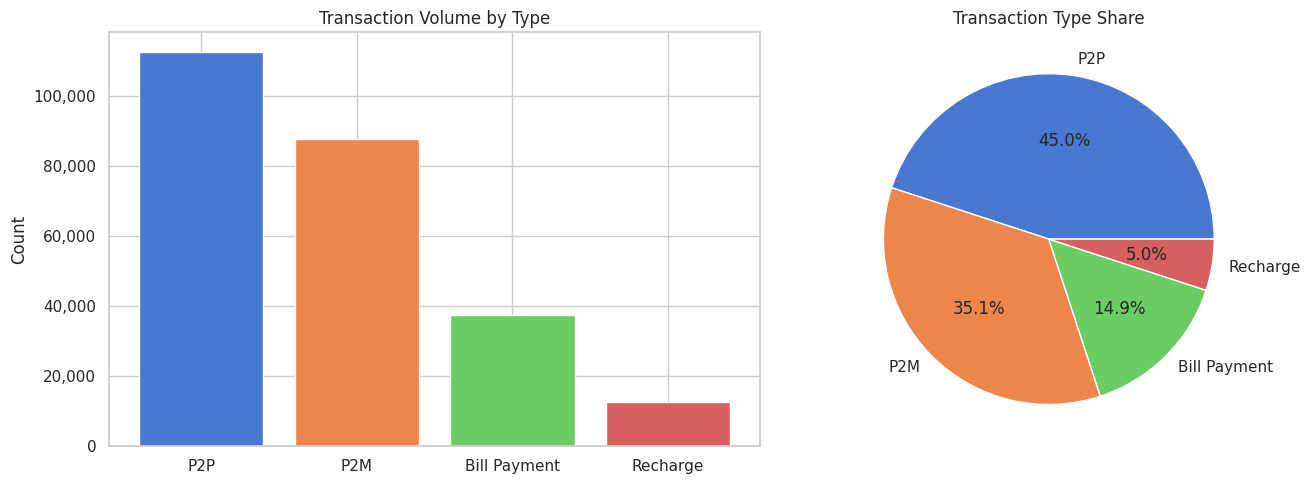

In [16]:
# --- Volume distribution by transaction type ---
type_counts = df['transaction type'].value_counts()
type_pct = (type_counts / len(df) * 100).round(2)

print('=== TRANSACTION TYPE DISTRIBUTION ===')
for t in type_counts.index:
    print(f'  {t}: {type_counts[t]:,} ({type_pct[t]}%)')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
axes[0].bar(type_counts.index, type_counts.values, color=sns.color_palette('muted', len(type_counts)))
axes[0].set_title('Transaction Volume by Type')
axes[0].set_ylabel('Count')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Pie chart
axes[1].pie(type_counts.values, labels=type_counts.index, autopct='%1.1f%%',
            colors=sns.color_palette('muted', len(type_counts)))
axes[1].set_title('Transaction Type Share')

plt.tight_layout()
plt.savefig('transaction_type_distribution.png', bbox_inches='tight')
plt.show()

=== AMOUNT STATS BY TRANSACTION TYPE ===
                     mean  median      std
transaction type                          
Bill Payment      1308.49   629.0  1826.58
P2M               1320.07   632.0  1856.64
P2P               1308.68   628.0  1846.57
Recharge          1290.90   618.0  1864.80


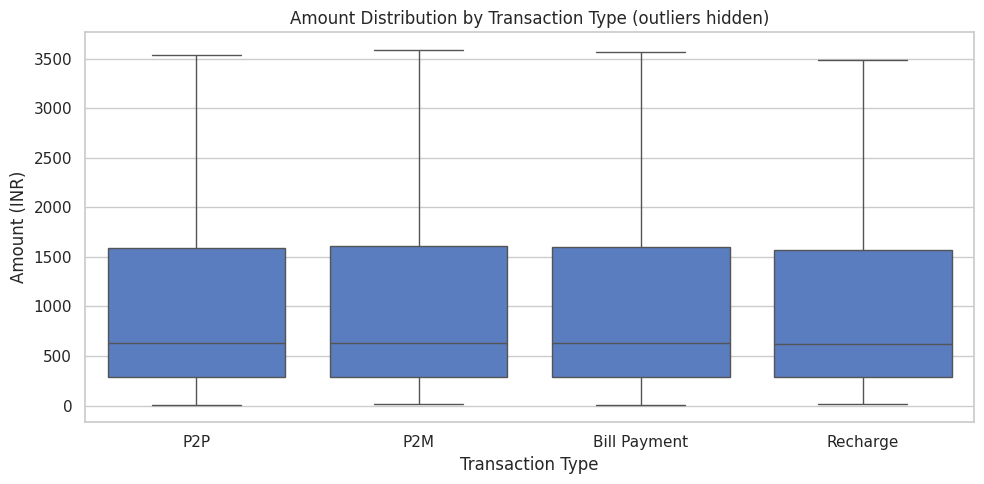

In [19]:
# --- Average amount by transaction type ---
amount_by_type = df.groupby('transaction type')['amount (INR)'].agg(['mean', 'median', 'std']).round(2)
print('=== AMOUNT STATS BY TRANSACTION TYPE ===')
print(amount_by_type)

plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='transaction type', y='amount (INR)', showfliers=False)
plt.title('Amount Distribution by Transaction Type (outliers hidden)')
plt.ylabel('Amount (INR)')
plt.xlabel('Transaction Type')
plt.tight_layout()
plt.savefig('amount_by_type_boxplot.png', bbox_inches='tight')
plt.show()

=== MERCHANT CATEGORY DISTRIBUTION (P2M) ===
merchant_category
Grocery          17345
Food             13132
Shopping         10451
Fuel              9005
Other             8682
Utilities         7881
Transport         7041
Entertainment     6989
Healthcare        4429
Education         2705
Name: count, dtype: int64


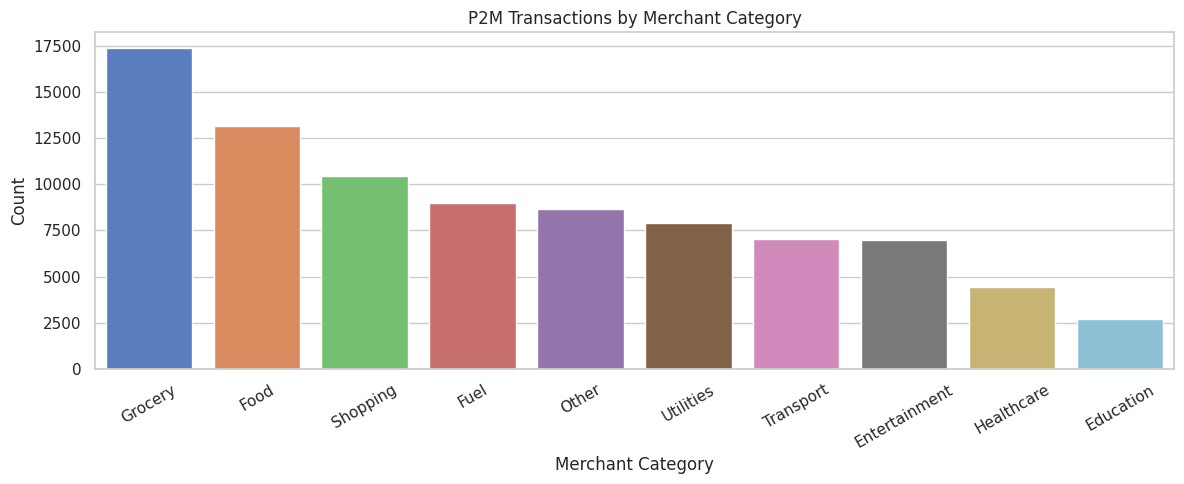

In [20]:
# --- Merchant category breakdown (P2M only) ---
p2m_df = df[df['transaction type'] == 'P2M'].copy()
cat_counts = p2m_df['merchant_category'].value_counts()

print('=== MERCHANT CATEGORY DISTRIBUTION (P2M) ===')
print(cat_counts)

plt.figure(figsize=(12, 5))
sns.barplot(x=cat_counts.index, y=cat_counts.values, palette='muted')
plt.title('P2M Transactions by Merchant Category')
plt.ylabel('Count')
plt.xlabel('Merchant Category')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('merchant_category_distribution.png', bbox_inches='tight')
plt.show()

## 4. Amount Distribution Analysis

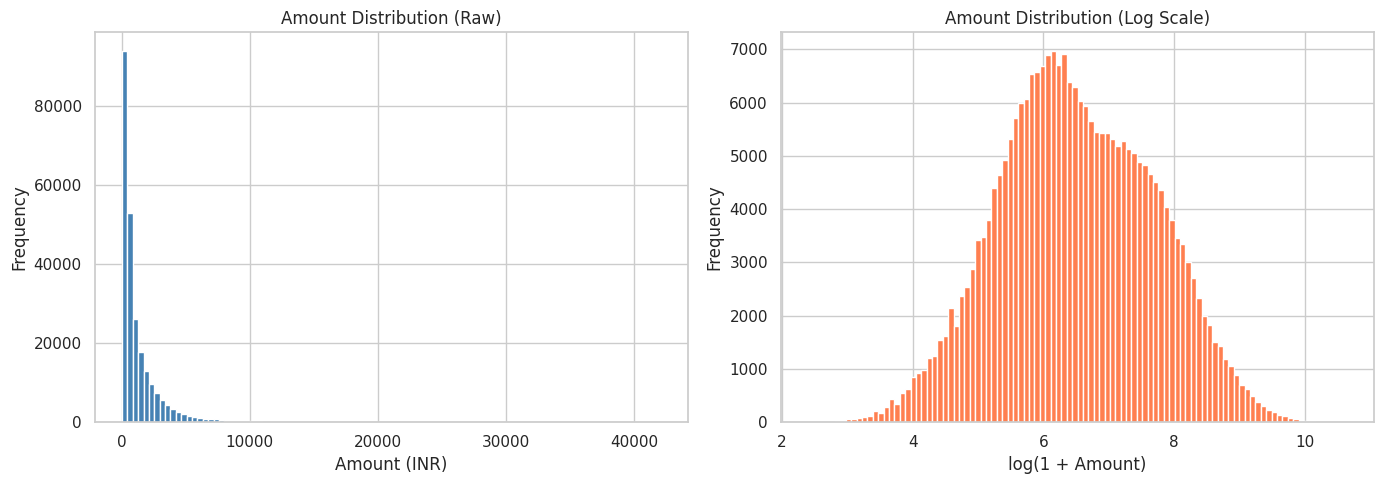

High-value threshold (P90): ₹3,236.00
High-value transactions: 25,012 (10.0%)


In [24]:
# --- Overall amount distribution ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw distribution
axes[0].hist(df['amount (INR)'], bins=100, color='steelblue', edgecolor='white')
axes[0].set_title('Amount Distribution (Raw)')
axes[0].set_xlabel('Amount (INR)')
axes[0].set_ylabel('Frequency')

# Log-scale for skewed data
axes[1].hist(np.log1p(df['amount (INR)']), bins=100, color='coral', edgecolor='white')
axes[1].set_title('Amount Distribution (Log Scale)')
axes[1].set_xlabel('log(1 + Amount)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('amount_distribution.png', bbox_inches='tight')
plt.show()

# Define high-value threshold (top 10%) — used throughout analytics engine
HIGH_VALUE_THRESHOLD = df['amount (INR)'].quantile(0.90)
print(f'High-value threshold (P90): ₹{HIGH_VALUE_THRESHOLD:,.2f}')
print(f'High-value transactions: {(df["amount (INR)"] >= HIGH_VALUE_THRESHOLD).sum():,} ({(df["amount (INR)"] >= HIGH_VALUE_THRESHOLD).mean()*100:.1f}%)')

=== AVERAGE AMOUNT BY MERCHANT CATEGORY ===
                      mean  median
merchant_category                 
Education          5134.08  3655.0
Shopping           2616.20  1617.0
Utilities          2324.46  1851.0
Fuel               1558.59  1042.0
Grocery            1170.48   816.0
Other               844.80   613.0
Healthcare          542.23   383.0
Food                532.59   331.0
Entertainment       418.08   299.0
Transport           309.61   191.0


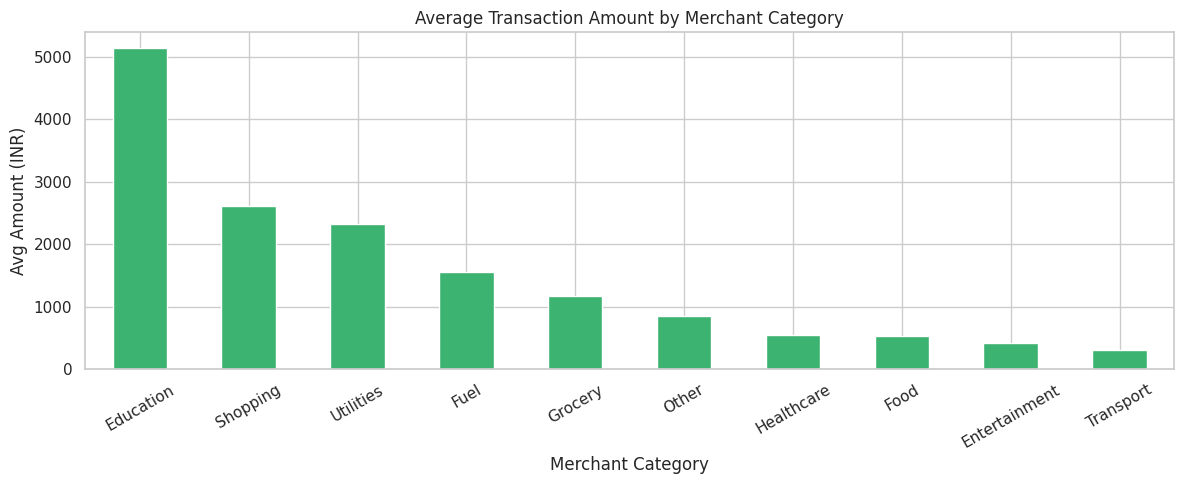

In [25]:
# --- Amount by merchant category (P2M only) ---
cat_amount = p2m_df.groupby('merchant_category')['amount (INR)'].agg(['mean', 'median']).round(2).sort_values('mean', ascending=False)
print('=== AVERAGE AMOUNT BY MERCHANT CATEGORY ===')
print(cat_amount)

plt.figure(figsize=(12, 5))
cat_amount['mean'].plot(kind='bar', color='mediumseagreen')
plt.title('Average Transaction Amount by Merchant Category')
plt.ylabel('Avg Amount (INR)')
plt.xlabel('Merchant Category')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('avg_amount_by_category.png', bbox_inches='tight')
plt.show()

## 5. Temporal Patterns

=== PEAK HOURS (Top 5 by volume) ===
    hour_of_day  count  failure_rate
19           19  21232          5.15
18           18  20064          4.85
20           20  18506          4.88
17           17  18340          4.97
12           12  17516          5.00


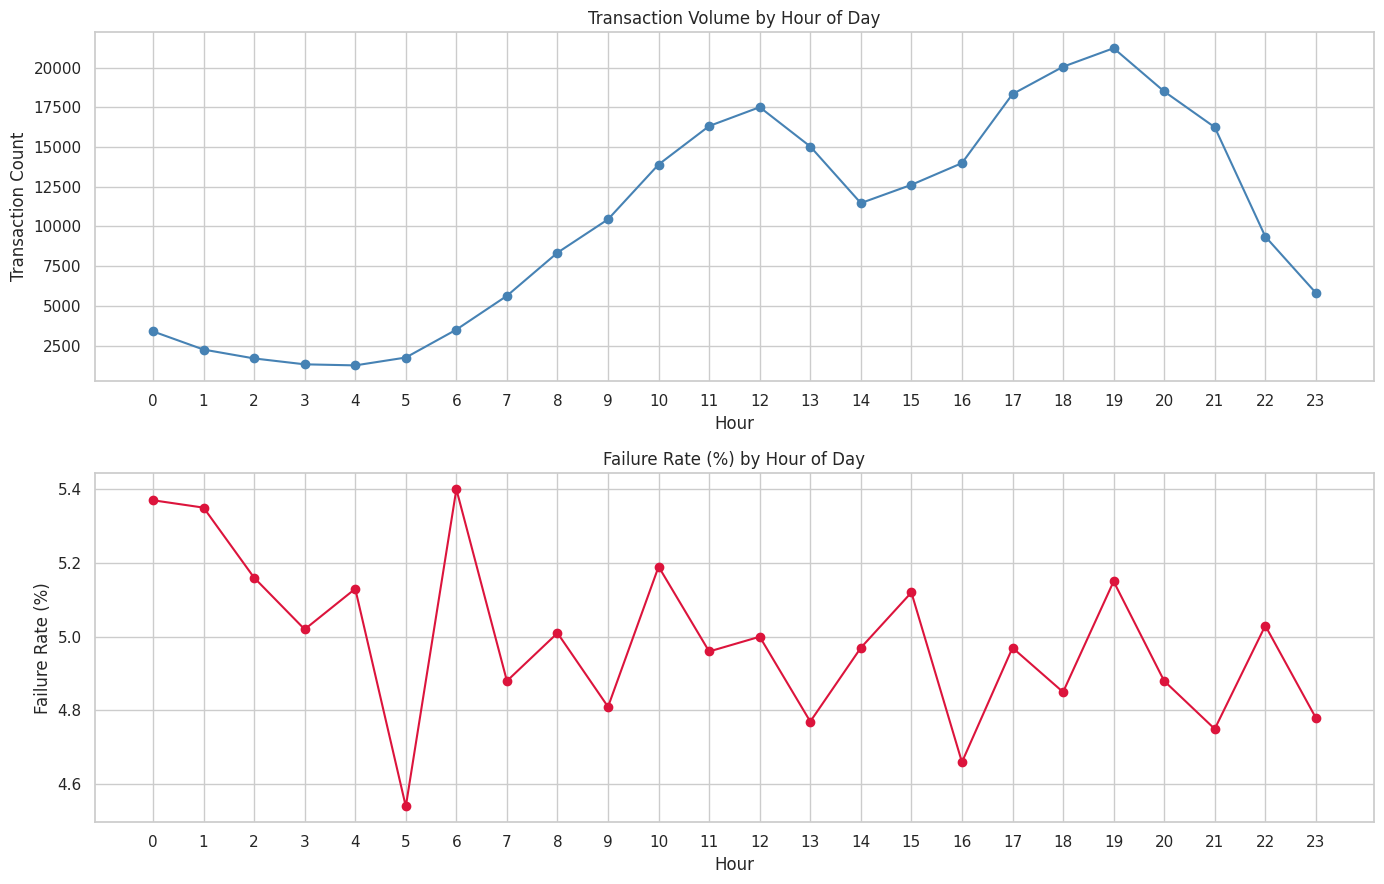

In [26]:
# --- Hourly transaction volume ---
hourly = df.groupby('hour_of_day').size().reset_index(name='count')
hourly_success = df[df['transaction_status'] == 'SUCCESS'].groupby('hour_of_day').size().reset_index(name='success')
hourly_fail = df[df['transaction_status'] == 'FAILED'].groupby('hour_of_day').size().reset_index(name='failed')
hourly = hourly.merge(hourly_success, on='hour_of_day').merge(hourly_fail, on='hour_of_day')
hourly['failure_rate'] = (hourly['failed'] / hourly['count'] * 100).round(2)

print('=== PEAK HOURS (Top 5 by volume) ===')
print(hourly.nlargest(5, 'count')[['hour_of_day', 'count', 'failure_rate']])

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

axes[0].plot(hourly['hour_of_day'], hourly['count'], marker='o', color='steelblue')
axes[0].set_title('Transaction Volume by Hour of Day')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Transaction Count')
axes[0].set_xticks(range(0, 24))

axes[1].plot(hourly['hour_of_day'], hourly['failure_rate'], marker='o', color='crimson')
axes[1].set_title('Failure Rate (%) by Hour of Day')
axes[1].set_xlabel('Hour')
axes[1].set_ylabel('Failure Rate (%)')
axes[1].set_xticks(range(0, 24))

plt.tight_layout()
plt.savefig('hourly_patterns.png', bbox_inches='tight')
plt.show()

=== DAY OF WEEK ANALYSIS ===
             count  failure_rate  avg_amount
day_of_week                                 
Monday       36495          4.96     1312.04
Tuesday      35540          4.79     1318.13
Wednesday    35700          4.99     1311.36
Thursday     35432          4.96     1315.79
Friday       35496          4.77     1305.29
Saturday     35334          5.09     1298.12
Sunday       36003          5.10     1321.35


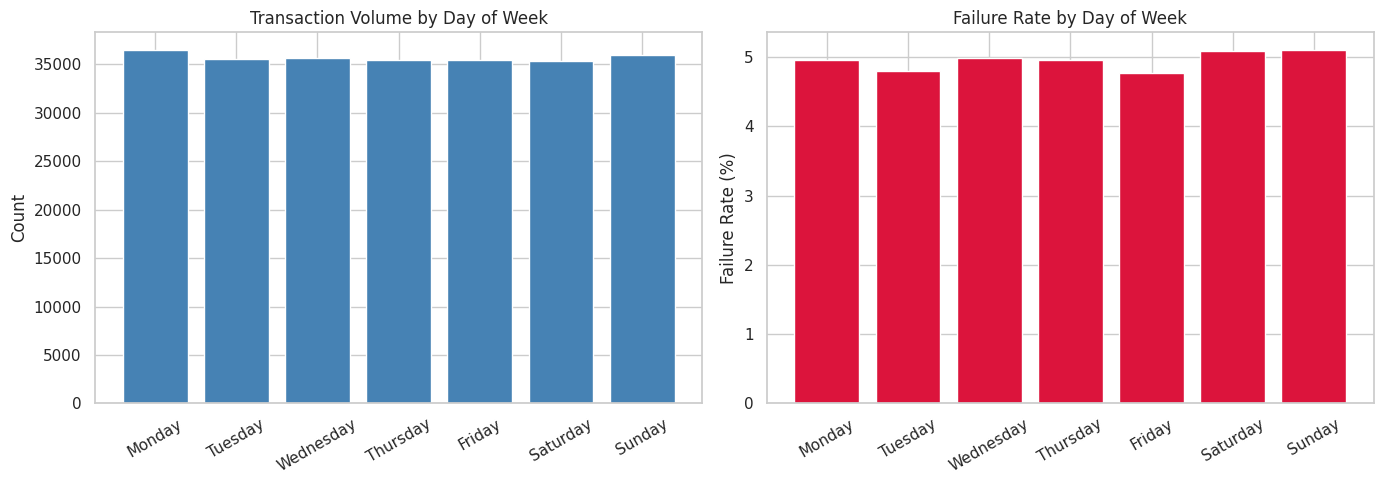

In [28]:
# --- Day of week patterns ---
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

if 'day_of_week' in df.columns:
    daily = df.groupby('day_of_week').agg(
        count=('transaction id', 'count'),
        failed=('transaction_status', lambda x: (x == 'FAILED').sum()),
        avg_amount=('amount (INR)', 'mean')
    ).round(2)
    daily['failure_rate'] = (daily['failed'] / daily['count'] * 100).round(2)

    # Reorder by day
    existing_days = [d for d in day_order if d in daily.index]
    daily = daily.reindex(existing_days)

    print('=== DAY OF WEEK ANALYSIS ===')
    print(daily[['count', 'failure_rate', 'avg_amount']])

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].bar(daily.index, daily['count'], color='steelblue')
    axes[0].set_title('Transaction Volume by Day of Week')
    axes[0].set_ylabel('Count')
    axes[0].tick_params(axis='x', rotation=30)

    axes[1].bar(daily.index, daily['failure_rate'], color='crimson')
    axes[1].set_title('Failure Rate by Day of Week')
    axes[1].set_ylabel('Failure Rate (%)')
    axes[1].tick_params(axis='x', rotation=30)

    plt.tight_layout()
    plt.savefig('daily_patterns.png', bbox_inches='tight')
    plt.show()

In [29]:
# --- Weekend vs Weekday comparison ---
weekend_comp = df.groupby('is_weekend').agg(
    total=('transaction id', 'count'),
    failed=('transaction_status', lambda x: (x == 'FAILED').sum()),
    avg_amount=('amount (INR)', 'mean'),
    fraud_flagged=('fraud_flag', 'sum')
).round(2)
weekend_comp['failure_rate'] = (weekend_comp['failed'] / weekend_comp['total'] * 100).round(2)
weekend_comp['fraud_flag_rate'] = (weekend_comp['fraud_flagged'] / weekend_comp['total'] * 100).round(2)
weekend_comp.index = ['Weekday', 'Weekend']

print('=== WEEKEND vs WEEKDAY ===')
print(weekend_comp)

=== WEEKEND vs WEEKDAY ===
          total  failed  avg_amount  fraud_flagged  failure_rate  \
Weekday  178663    8744     1312.52            337          4.89   
Weekend   71337    3632     1309.85            143          5.09   

         fraud_flag_rate  
Weekday             0.19  
Weekend             0.20  


## 6. Failure Rate Analysis

In [30]:
# --- Overall success/failure split ---
status_counts = df['transaction_status'].value_counts()
print('=== OVERALL TRANSACTION STATUS ===')
for s, c in status_counts.items():
    print(f'  {s}: {c:,} ({c/len(df)*100:.2f}%)')

=== OVERALL TRANSACTION STATUS ===
  SUCCESS: 237,624 (95.05%)
  FAILED: 12,376 (4.95%)



=== FAILURE RATE BY TRANSACTION TYPE ===
                   total  failed  failure_rate_pct
transaction type                                  
Recharge           12527     638              5.09
P2P               112445    5575              4.96
P2M                87660    4339              4.95
Bill Payment       37368    1824              4.88

=== FAILURE RATE BY SENDER BANK ===
             total  failed  failure_rate_pct
sender_bank                                 
Yes Bank     24860    1269              5.10
ICICI        29769    1499              5.04
Kotak        20032     998              4.98
Axis         25042    1239              4.95
IndusInd     25173    1247              4.95
SBI          62693    3095              4.94
PNB          24946    1221              4.89
HDFC         37485    1808              4.82

=== FAILURE RATE BY DEVICE TYPE ===
              total  failed  failure_rate_pct
device_type                                  
Web           12610     650         

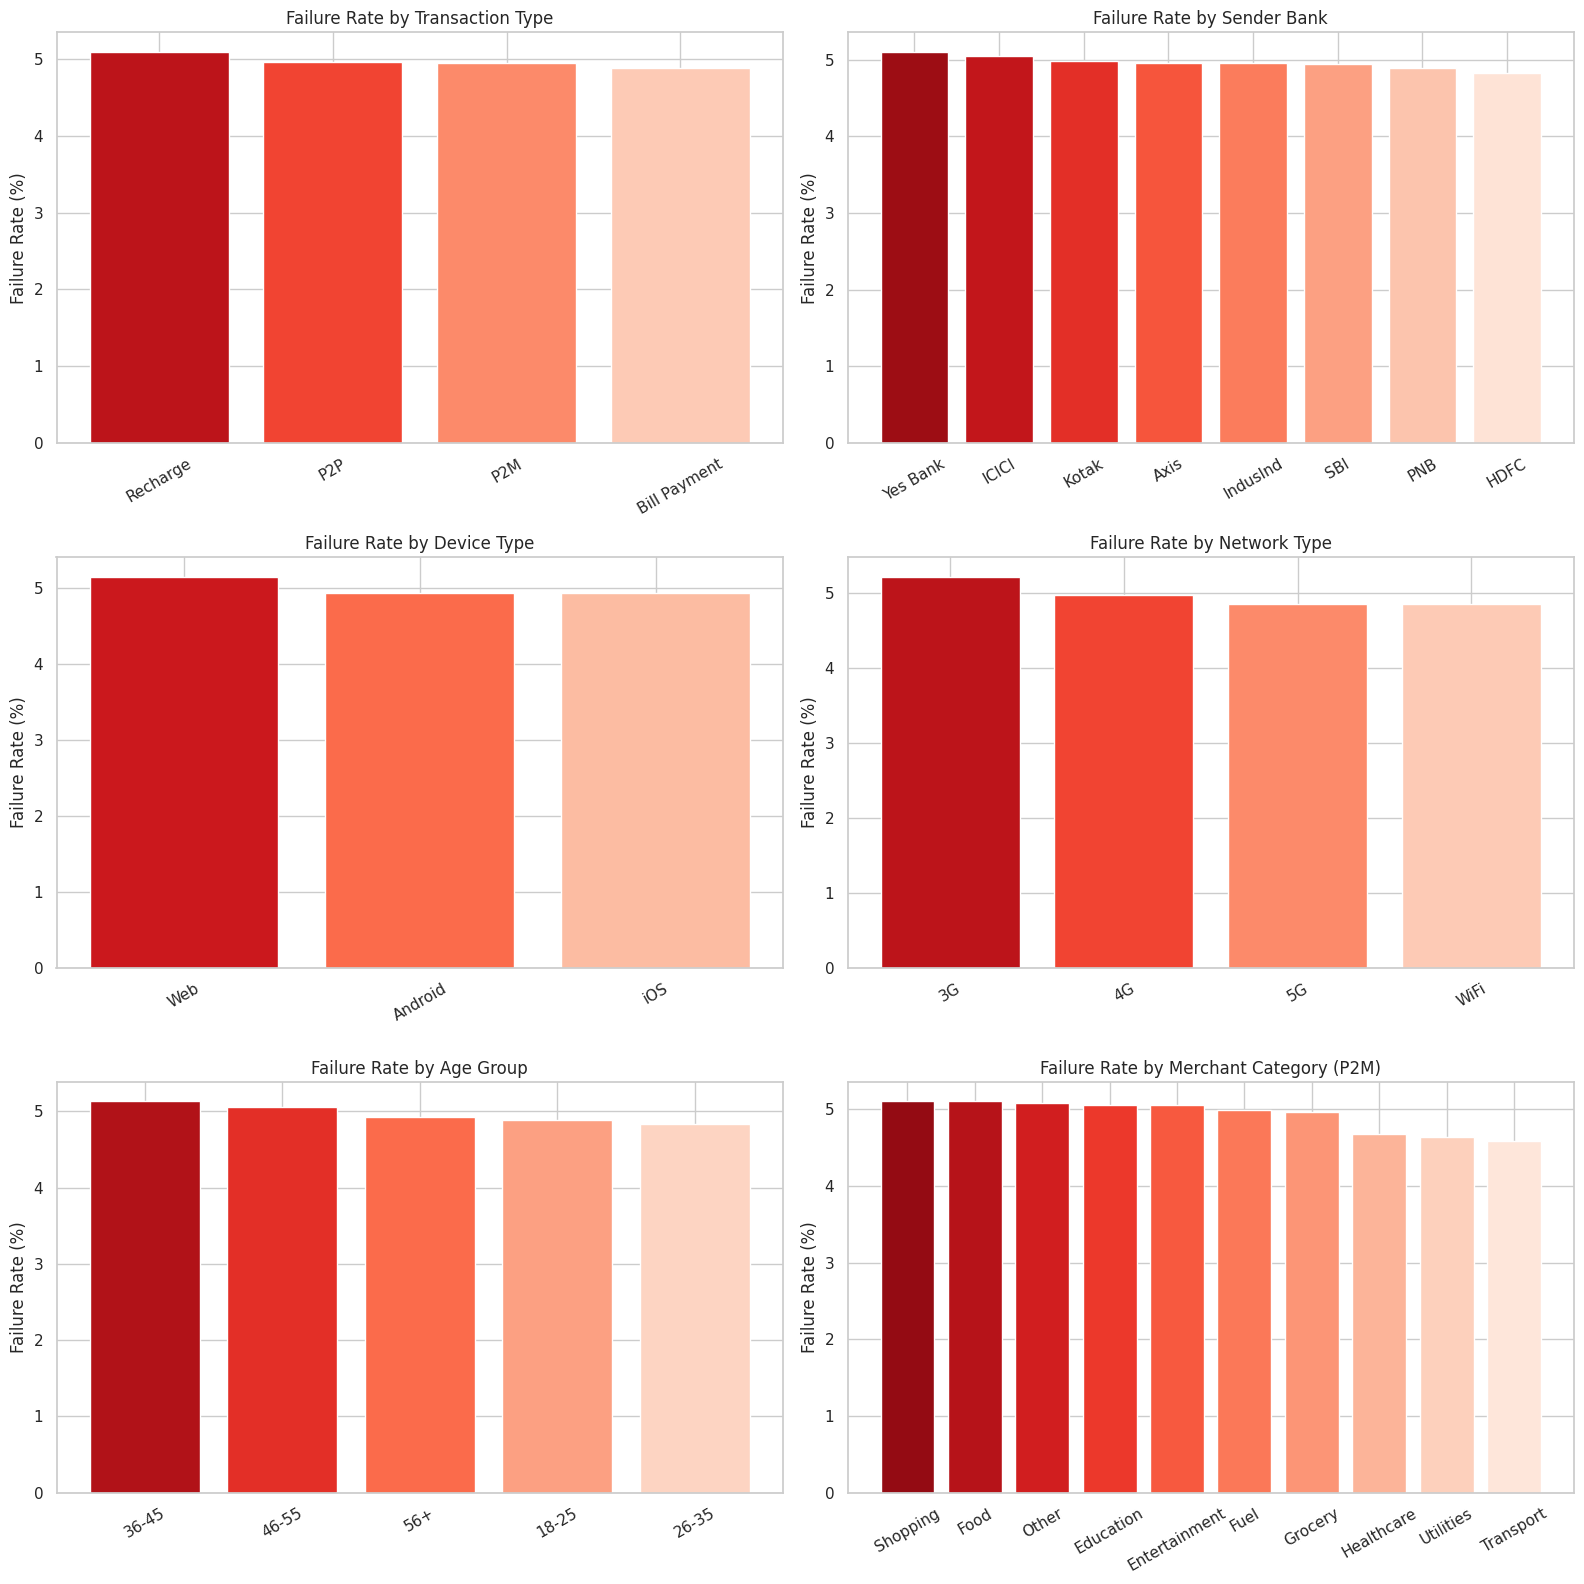

In [32]:
# --- Failure rate by every major dimension ---
def failure_rate_by(col, df=df, top_n=None):
    """Compute failure rate grouped by a column."""
    grp = df.groupby(col)['transaction_status'].agg(
        total='count',
        failed=lambda x: (x == 'FAILED').sum()
    )
    grp['failure_rate_pct'] = (grp['failed'] / grp['total'] * 100).round(2)
    grp = grp.sort_values('failure_rate_pct', ascending=False)
    if top_n:
        grp = grp.head(top_n)
    return grp

dims = [
    ('transaction type', 'Failure Rate by Transaction Type'),
    ('sender_bank', 'Failure Rate by Sender Bank'),
    ('device_type', 'Failure Rate by Device Type'),
    ('network_type', 'Failure Rate by Network Type'),
    ('sender_age_group', 'Failure Rate by Age Group'),
]

fig, axes = plt.subplots(3, 2, figsize=(16, 16))
axes = axes.flatten()

for i, (col, title) in enumerate(dims):
    fr = failure_rate_by(col)
    print(f'\n=== {title.upper()} ===')
    print(fr)
    axes[i].bar(fr.index.astype(str), fr['failure_rate_pct'],
                color=sns.color_palette('Reds_r', len(fr)))
    axes[i].set_title(title)
    axes[i].set_ylabel('Failure Rate (%)')
    axes[i].tick_params(axis='x', rotation=30)

# Merchant category failure rate (P2M only)
fr_cat = failure_rate_by('merchant_category', df=p2m_df)
print(f'\n=== FAILURE RATE BY MERCHANT CATEGORY ===')
print(fr_cat)
axes[5].bar(fr_cat.index.astype(str), fr_cat['failure_rate_pct'],
            color=sns.color_palette('Reds_r', len(fr_cat)))
axes[5].set_title('Failure Rate by Merchant Category (P2M)')
axes[5].set_ylabel('Failure Rate (%)')
axes[5].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('failure_rates_all_dims.png', bbox_inches='tight')
plt.show()

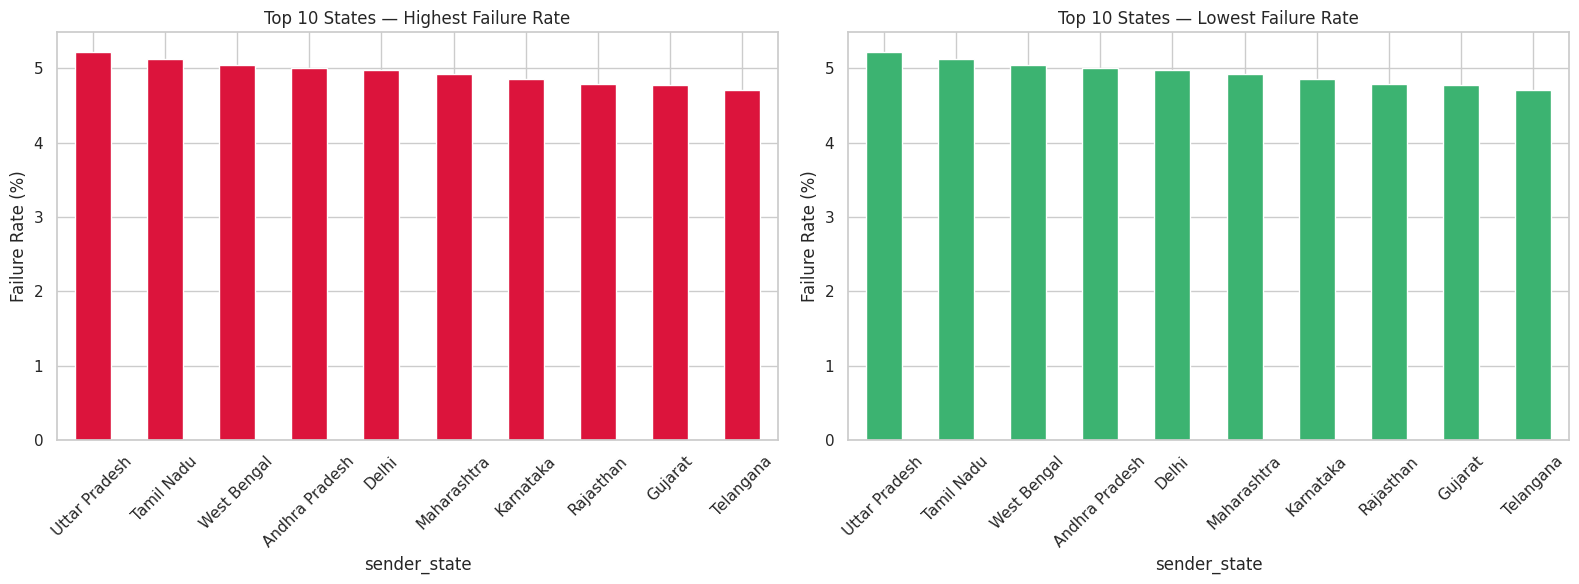

In [33]:
# --- Failure rate by state (top 10 and bottom 10) ---
fr_state = failure_rate_by('sender_state')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fr_state.head(10)['failure_rate_pct'].plot(kind='bar', ax=axes[0], color='crimson')
axes[0].set_title('Top 10 States — Highest Failure Rate')
axes[0].set_ylabel('Failure Rate (%)')
axes[0].tick_params(axis='x', rotation=45)

fr_state.tail(10)['failure_rate_pct'].plot(kind='bar', ax=axes[1], color='mediumseagreen')
axes[1].set_title('Top 10 States — Lowest Failure Rate')
axes[1].set_ylabel('Failure Rate (%)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('failure_rate_by_state.png', bbox_inches='tight')
plt.show()

## 7. Demographic & Geographic Analysis

=== AGE GROUP ANALYSIS ===
                  total  avg_amount  median_amount  failed  failure_rate  \
sender_age_group                                                           
18-25             62345     1194.55          611.0    3046          4.89   
26-35             87432     1326.29          641.0    4236          4.84   
36-45             62873     1424.04          657.0    3223          5.13   
46-55             24841     1333.13          603.0    1256          5.06   
56+               12509     1187.57          552.0     615          4.92   

                  volume_share  
sender_age_group                
18-25                    24.94  
26-35                    34.97  
36-45                    25.15  
46-55                     9.94  
56+                       5.00  


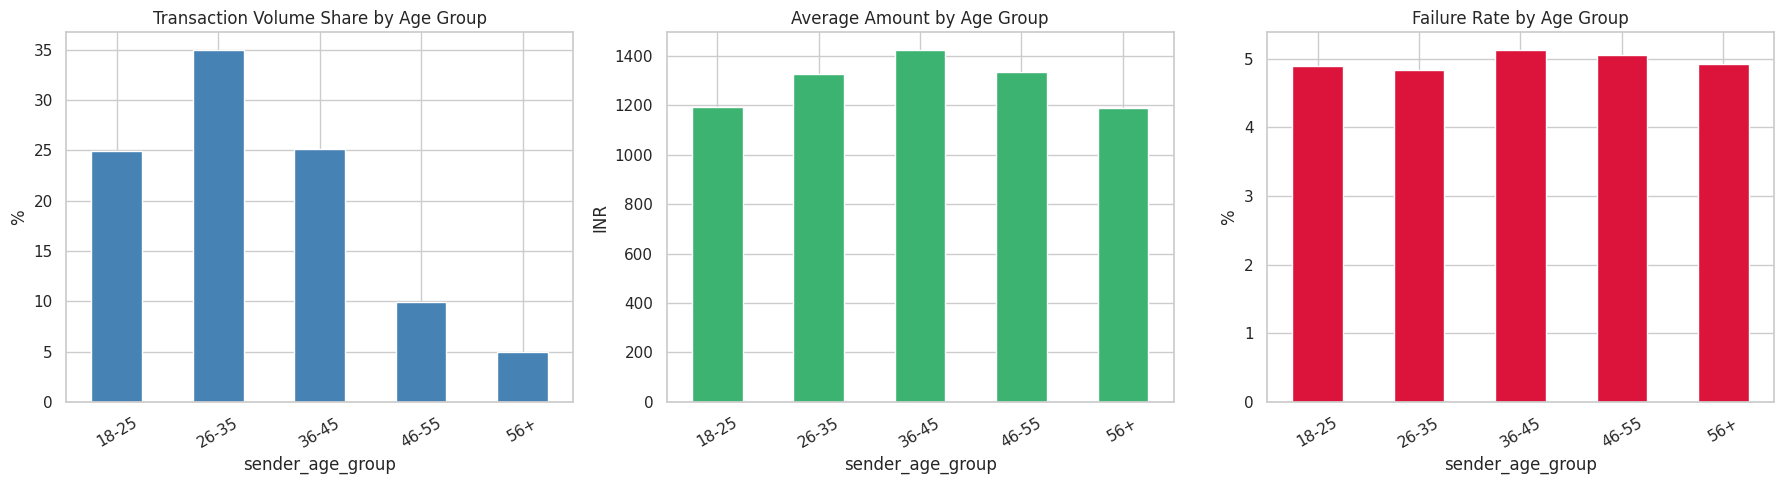

In [37]:
# --- Age group analysis ---
age_stats = df.groupby('sender_age_group').agg(
    total=('transaction id', 'count'),
    avg_amount=('amount (INR)', 'mean'),
    median_amount=('amount (INR)', 'median'),
    failed=('transaction_status', lambda x: (x == 'FAILED').sum())
).round(2)
age_stats['failure_rate'] = (age_stats['failed'] / age_stats['total'] * 100).round(2)
age_stats['volume_share'] = (age_stats['total'] / age_stats['total'].sum() * 100).round(2)

print('=== AGE GROUP ANALYSIS ===')
print(age_stats)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
age_stats['volume_share'].plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Transaction Volume Share by Age Group')
axes[0].set_ylabel('%')

age_stats['avg_amount'].plot(kind='bar', ax=axes[1], color='mediumseagreen')
axes[1].set_title('Average Amount by Age Group')
axes[1].set_ylabel('INR')

age_stats['failure_rate'].plot(kind='bar', ax=axes[2], color='crimson')
axes[2].set_title('Failure Rate by Age Group')
axes[2].set_ylabel('%')

for ax in axes:
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('age_group_analysis.png', bbox_inches='tight')
plt.show()

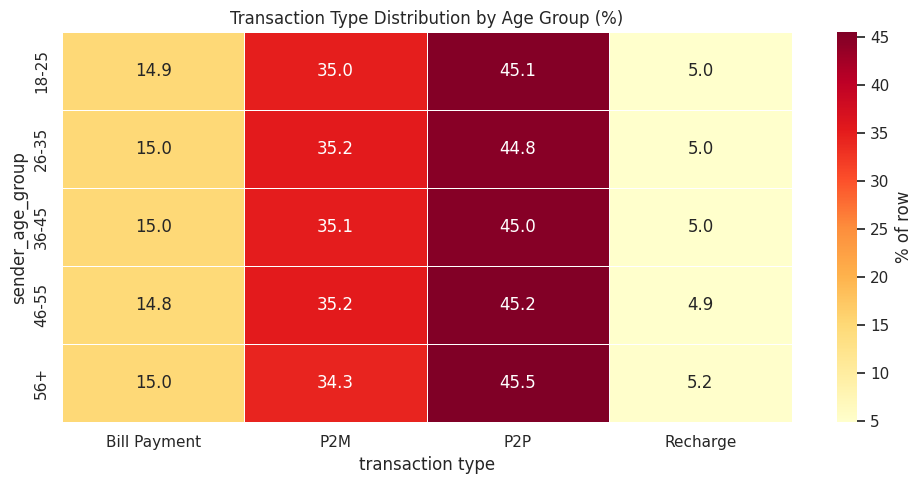

In [39]:
# --- Age group × transaction type heatmap ---
age_type = df.groupby(['sender_age_group', 'transaction type']).size().unstack(fill_value=0)
age_type_pct = age_type.div(age_type.sum(axis=1), axis=0) * 100

plt.figure(figsize=(10, 5))
sns.heatmap(age_type_pct.round(1), annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': '% of row'})
plt.title('Transaction Type Distribution by Age Group (%)')
plt.tight_layout()
plt.savefig('age_type_heatmap.png', bbox_inches='tight')
plt.show()

=== TOP 10 STATES BY TRANSACTION VOLUME ===
                total  avg_amount  failure_rate
sender_state                                   
Maharashtra     37427     1310.39          4.92
Uttar Pradesh   30125     1328.99          5.22
Karnataka       29756     1292.22          4.86
Tamil Nadu      25367     1314.44          5.12
Delhi           24870     1314.43          4.97
Telangana       22435     1326.09          4.71
Gujarat         20061     1295.46          4.78
Andhra Pradesh  20006     1297.24          5.00
Rajasthan       19981     1337.79          4.79
West Bengal     19972     1299.45          5.04


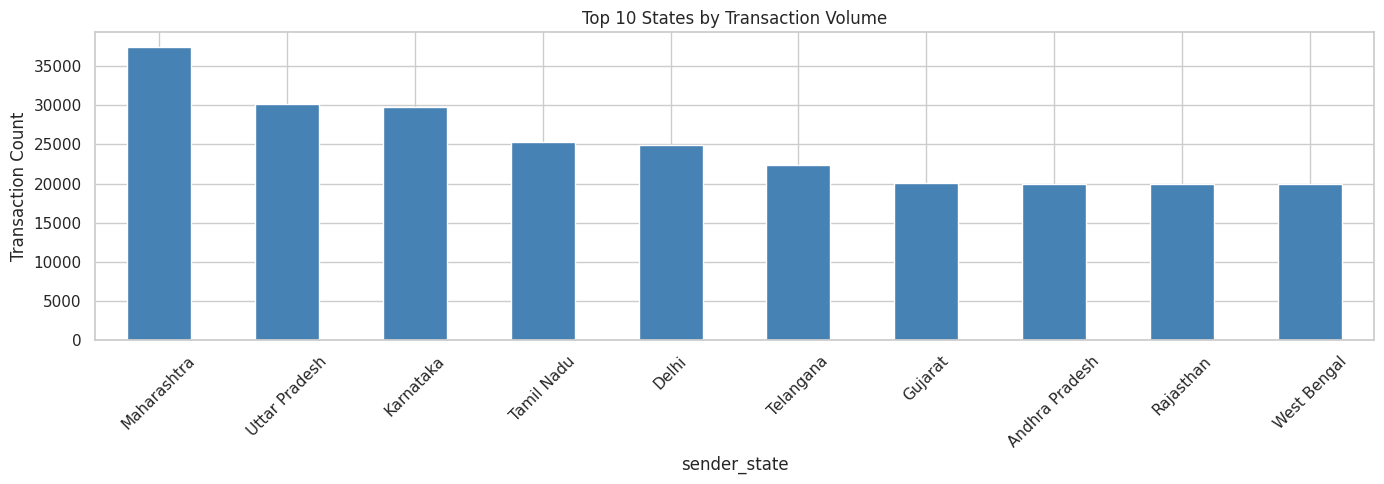

In [41]:
# --- Top 10 states by volume and avg amount ---
state_stats = df.groupby('sender_state').agg(
    total=('transaction id', 'count'),
    avg_amount=('amount (INR)', 'mean'),
    failed=('transaction_status', lambda x: (x == 'FAILED').sum())
).round(2)
state_stats['failure_rate'] = (state_stats['failed'] / state_stats['total'] * 100).round(2)

print('=== TOP 10 STATES BY TRANSACTION VOLUME ===')
print(state_stats.nlargest(10, 'total')[['total', 'avg_amount', 'failure_rate']])

plt.figure(figsize=(14, 5))
state_stats.nlargest(10, 'total')['total'].plot(kind='bar', color='steelblue')
plt.title('Top 10 States by Transaction Volume')
plt.ylabel('Transaction Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('top_states_volume.png', bbox_inches='tight')
plt.show()

## 8. Device & Network Analysis

In [43]:
# --- Device type breakdown ---
device_stats = df.groupby('device_type').agg(
    total=('transaction id', 'count'),
    failed=('transaction_status', lambda x: (x == 'FAILED').sum()),
    avg_amount=('amount (INR)', 'mean')
).round(2)
device_stats['failure_rate'] = (device_stats['failed'] / device_stats['total'] * 100).round(2)
device_stats['volume_share'] = (device_stats['total'] / device_stats['total'].sum() * 100).round(2)

print('=== DEVICE TYPE ANALYSIS ===')
print(device_stats)

# Network type breakdown
network_stats = df.groupby('network_type').agg(
    total=('transaction id', 'count'),
    failed=('transaction_status', lambda x: (x == 'FAILED').sum()),
    avg_amount=('amount (INR)', 'mean')
).round(2)
network_stats['failure_rate'] = (network_stats['failed'] / network_stats['total'] * 100).round(2)

print('\n=== NETWORK TYPE ANALYSIS ===')
print(network_stats)

=== DEVICE TYPE ANALYSIS ===
              total  failed  avg_amount  failure_rate  volume_share
device_type                                                        
Android      187777    9278     1313.98          4.94         75.11
Web           12610     650     1300.81          5.15          5.04
iOS           49613    2448     1306.10          4.93         19.85

=== NETWORK TYPE ANALYSIS ===
               total  failed  avg_amount  failure_rate
network_type                                          
3G             12471     651     1325.88          5.22
4G            149813    7464     1305.88          4.98
5G             62582    3039     1316.06          4.86
WiFi           25134    1222     1329.05          4.86


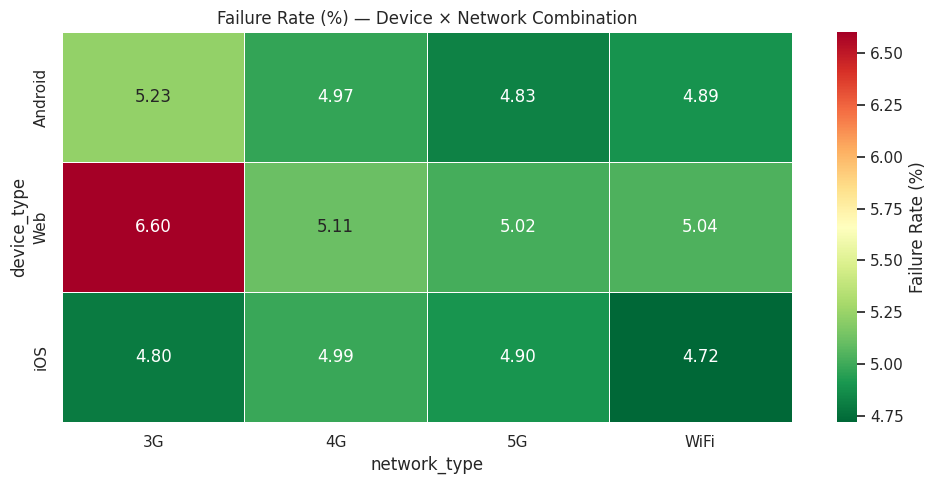

In [44]:
# --- Device × Network reliability heatmap ---
device_network = df.groupby(['device_type', 'network_type'])['transaction_status'].apply(
    lambda x: (x == 'FAILED').sum() / len(x) * 100
).round(2).unstack(fill_value=0)

plt.figure(figsize=(10, 5))
sns.heatmap(device_network, annot=True, fmt='.2f', cmap='RdYlGn_r',
            linewidths=0.5, cbar_kws={'label': 'Failure Rate (%)'})
plt.title('Failure Rate (%) — Device × Network Combination')
plt.tight_layout()
plt.savefig('device_network_heatmap.png', bbox_inches='tight')
plt.show()

## 9. Fraud Flag Analysis

In [46]:
# --- Overall fraud flag rate ---
total_flagged = df['fraud_flag'].sum()
flag_rate = total_flagged / len(df) * 100
print(f'Total flagged transactions: {total_flagged:,} ({flag_rate:.2f}%)')
print('NOTE: fraud_flag = 1 means flagged for review, NOT confirmed fraud')

# High-value flag rate
hv_df = df[df['amount (INR)'] >= HIGH_VALUE_THRESHOLD]
hv_flag_rate = hv_df['fraud_flag'].mean() * 100
print(f'\nHigh-value (P90+) flag rate: {hv_flag_rate:.2f}%')
print(f'Overall flag rate: {flag_rate:.2f}%')
print(f'Relative concentration in high-value: {hv_flag_rate/flag_rate:.2f}x')

Total flagged transactions: 480 (0.19%)
NOTE: fraud_flag = 1 means flagged for review, NOT confirmed fraud

High-value (P90+) flag rate: 0.25%
Overall flag rate: 0.19%
Relative concentration in high-value: 1.31x


In [48]:
# --- Flag rate by major dimensions ---
def flag_rate_by(col, data=df):
    grp = data.groupby(col)['fraud_flag'].agg(['sum', 'count'])
    grp['flag_rate_pct'] = (grp['sum'] / grp['count'] * 100).round(2)
    return grp.sort_values('flag_rate_pct', ascending=False)

flag_dims = ['transaction type', 'network_type', 'device_type', 'sender_bank', 'sender_age_group']
for col in flag_dims:
    print(f'\n=== FRAUD FLAG RATE BY {col.upper()} ===')
    print(flag_rate_by(col)[['sum', 'count', 'flag_rate_pct']])


=== FRAUD FLAG RATE BY TRANSACTION TYPE ===
                  sum   count  flag_rate_pct
transaction type                            
Recharge           30   12527           0.24
Bill Payment       77   37368           0.21
P2M               167   87660           0.19
P2P               206  112445           0.18

=== FRAUD FLAG RATE BY NETWORK_TYPE ===
              sum   count  flag_rate_pct
network_type                            
WiFi           59   25134           0.23
3G             24   12471           0.19
4G            282  149813           0.19
5G            115   62582           0.18

=== FRAUD FLAG RATE BY DEVICE_TYPE ===
             sum   count  flag_rate_pct
device_type                            
Web           26   12610           0.21
Android      364  187777           0.19
iOS           90   49613           0.18

=== FRAUD FLAG RATE BY SENDER_BANK ===
             sum  count  flag_rate_pct
sender_bank                           
Kotak         50  20032           0.25
I

=== TRANSACTION STATUS DISTRIBUTION WITHIN FLAG GROUPS ===
transaction_status  FAILED  SUCCESS
Not Flagged           4.95    95.05
Flagged               4.38    95.62


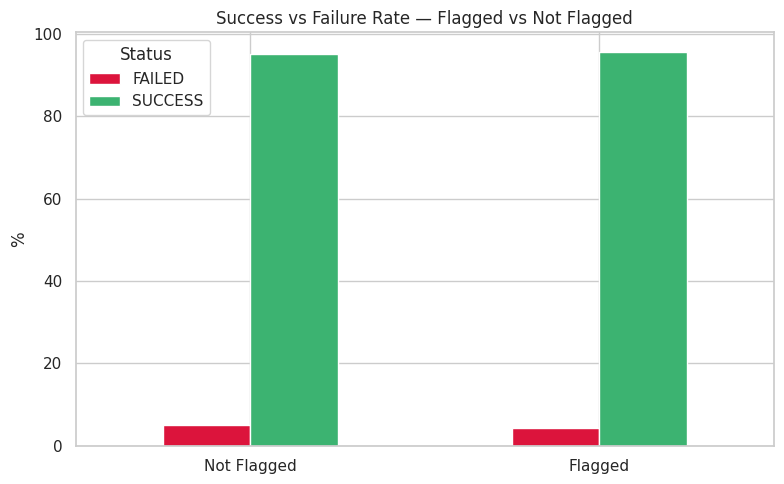

In [50]:
# --- Flag rate × transaction status cross-tab ---
cross = pd.crosstab(df['fraud_flag'], df['transaction_status'], normalize='index') * 100
cross.index = ['Not Flagged', 'Flagged']
print('=== TRANSACTION STATUS DISTRIBUTION WITHIN FLAG GROUPS ===')
print(cross.round(2))

cross.plot(kind='bar', color=['crimson', 'mediumseagreen'], figsize=(8, 5))
plt.title('Success vs Failure Rate — Flagged vs Not Flagged')
plt.ylabel('%')
plt.xticks(rotation=0)
plt.legend(title='Status')
plt.tight_layout()
plt.savefig('fraud_flag_status_crosstab.png', bbox_inches='tight')
plt.show()

## 10. Correlation & Cross-Segment Analysis

=== CORRELATION MATRIX ===
              amount (INR)  fraud_flag  is_failed  hour_of_day  is_weekend
amount (INR)         1.000       0.004      0.005       -0.002      -0.001
fraud_flag           0.004       1.000     -0.001        0.001       0.001
is_failed            0.005      -0.001      1.000       -0.003       0.004
hour_of_day         -0.002       0.001     -0.003        1.000       0.001
is_weekend          -0.001       0.001      0.004        0.001       1.000


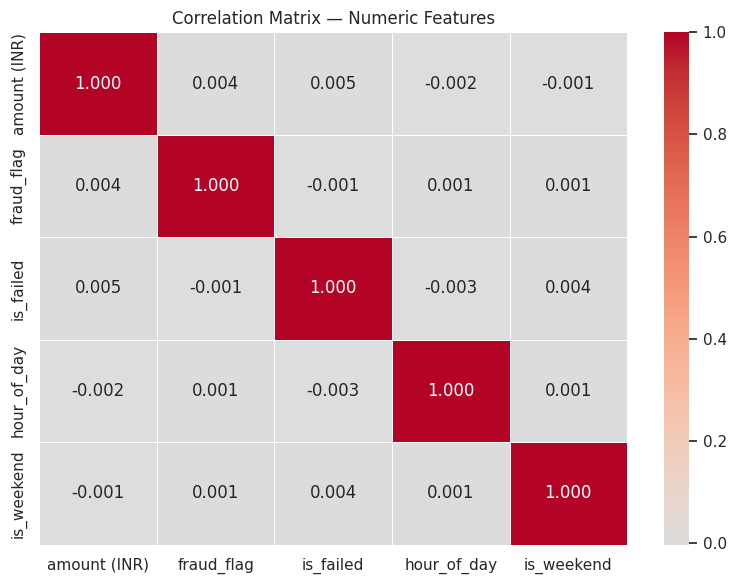

In [51]:
# --- Encode binary columns for correlation ---
df['is_failed'] = (df['transaction_status'] == 'FAILED').astype(int)

# Numeric correlation matrix
num_cols = ['amount (INR)', 'fraud_flag', 'is_failed', 'hour_of_day', 'is_weekend']
existing_num = [c for c in num_cols if c in df.columns]
corr_matrix = df[existing_num].corr().round(3)

print('=== CORRELATION MATRIX ===')
print(corr_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, linewidths=0.5)
plt.title('Correlation Matrix — Numeric Features')
plt.tight_layout()
plt.savefig('correlation_matrix.png', bbox_inches='tight')
plt.show()

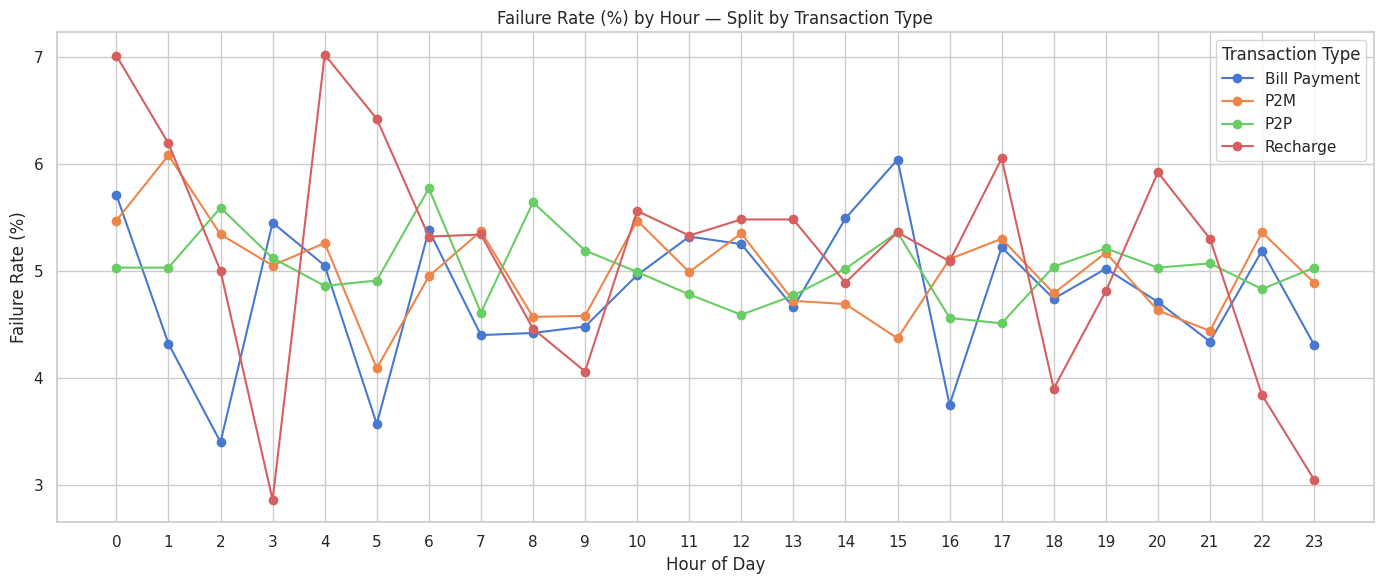

In [53]:
# --- Peak hour failure rates by transaction type ---
pivot = df.groupby(['hour_of_day', 'transaction type'])['is_failed'].mean().unstack() * 100
pivot = pivot.round(2)

plt.figure(figsize=(14, 6))
for col in pivot.columns:
    plt.plot(pivot.index, pivot[col], marker='o', label=col)
plt.title('Failure Rate (%) by Hour — Split by Transaction Type')
plt.xlabel('Hour of Day')
plt.ylabel('Failure Rate (%)')
plt.xticks(range(0, 24))
plt.legend(title='Transaction Type')
plt.tight_layout()
plt.savefig('hourly_failure_by_type.png', bbox_inches='tight')
plt.show()

In [54]:
# --- Bank pair analysis (sender→receiver) for P2P ---
p2p_df = df[df['transaction type'] == 'P2P'].copy()
bank_pair = p2p_df.groupby(['sender_bank', 'receiver_bank'])['is_failed'].agg(['mean', 'count'])
bank_pair['failure_rate'] = (bank_pair['mean'] * 100).round(2)
bank_pair = bank_pair[bank_pair['count'] >= 50]  # filter low-sample pairs

print('=== TOP 10 BANK PAIRS WITH HIGHEST FAILURE RATE (P2P, min 50 txns) ===')
print(bank_pair.nlargest(10, 'failure_rate')[['count', 'failure_rate']])

=== TOP 10 BANK PAIRS WITH HIGHEST FAILURE RATE (P2P, min 50 txns) ===
                           count  failure_rate
sender_bank receiver_bank                     
Yes Bank    Kotak            941          6.59
            Axis            1120          6.16
Kotak       Kotak            699          6.01
Axis        Kotak            895          5.92
Yes Bank    HDFC            1721          5.81
Kotak       IndusInd         953          5.77
HDFC        HDFC            2603          5.72
ICICI       ICICI           1642          5.66
Kotak       SBI             2211          5.65
Axis        IndusInd        1171          5.55


=== P2P USAGE BY AGE GROUP — WEEKEND vs WEEKDAY (%) ===
                  Weekend  Weekday
sender_age_group                  
26-35               34.96    34.75
36-45               25.38    25.04
18-25               24.97    25.02
46-55                9.68    10.10
56+                  5.01     5.09


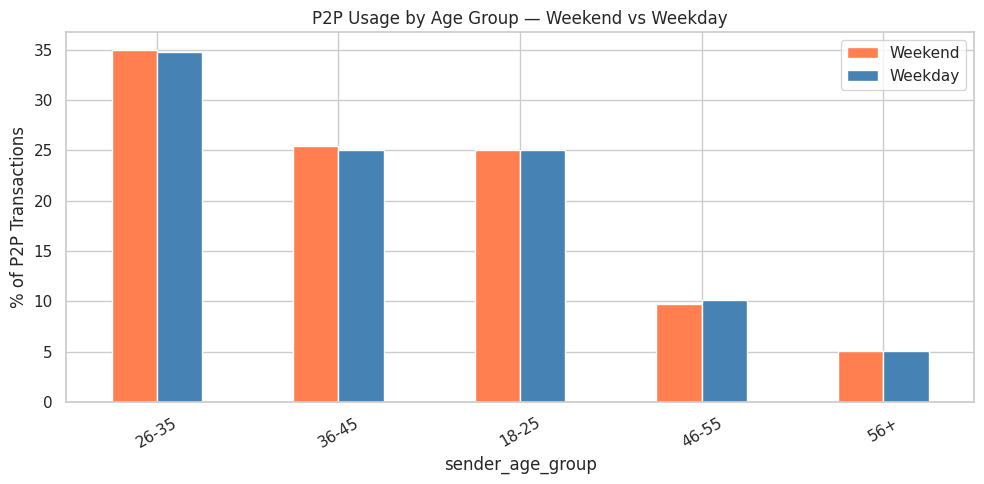

In [55]:
# --- Weekend P2P usage by age group ---
weekend_p2p = df[(df['transaction type'] == 'P2P') & (df['is_weekend'] == 1)]
weekday_p2p = df[(df['transaction type'] == 'P2P') & (df['is_weekend'] == 0)]

age_weekend = weekend_p2p['sender_age_group'].value_counts(normalize=True) * 100
age_weekday = weekday_p2p['sender_age_group'].value_counts(normalize=True) * 100

age_compare = pd.DataFrame({'Weekend': age_weekend, 'Weekday': age_weekday}).fillna(0).round(2)
print('=== P2P USAGE BY AGE GROUP — WEEKEND vs WEEKDAY (%) ===')
print(age_compare)

age_compare.plot(kind='bar', figsize=(10, 5), color=['coral', 'steelblue'])
plt.title('P2P Usage by Age Group — Weekend vs Weekday')
plt.ylabel('% of P2P Transactions')
plt.xticks(rotation=30)
plt.legend()
plt.tight_layout()
plt.savefig('p2p_age_weekend.png', bbox_inches='tight')
plt.show()

## 11. Key Findings Summary

In [57]:
# --- Auto-generate key stats that will seed the analytics engine ---
print('=' * 60)
print('KEY FINDINGS SUMMARY — InsightX Analytics Engine Seeds')
print('=' * 60)

# 1. Overall stats
overall_fail = (df['transaction_status'] == 'FAILED').mean() * 100
print(f'\n[OVERALL]')
print(f'  Total transactions: {len(df):,}')
print(f'  Overall failure rate: {overall_fail:.2f}%')
print(f'  Overall fraud flag rate: {df["fraud_flag"].mean()*100:.2f}%')
print(f'  Date range: {df["timestamp"].min().date()} → {df["timestamp"].max().date()}')

# 2. Failure rates by type
print(f'\n[FAILURE RATES BY TRANSACTION TYPE]')
for t_type, grp in df.groupby('transaction type'):
    fr = (grp['transaction_status'] == 'FAILED').mean() * 100
    print(f'  {t_type}: {fr:.2f}%')

# 3. Peak hours
peak_hour = hourly.loc[hourly['count'].idxmax(), 'hour_of_day']
print(f'\n[TEMPORAL]')
print(f'  Peak transaction hour: {peak_hour}:00')
print(f'  Weekend vs weekday failure rate diff: check weekend_comp above')

# 4. High-value threshold
print(f'\n[AMOUNTS]')
print(f'  High-value threshold (P90): ₹{HIGH_VALUE_THRESHOLD:,.2f}')
print(f'  High-value fraud flag rate: {hv_flag_rate:.2f}%')
print(f'  Overall fraud flag rate: {flag_rate:.2f}%')

print(f'\n[NEXT STEPS]')
print('  → Use these baselines to validate analytics_engine.py outputs')
print('  → Document anomalies found here in docs/approach.md')
print('  → HIGH_VALUE_THRESHOLD should be a constant in data_loader.py')

KEY FINDINGS SUMMARY — InsightX Analytics Engine Seeds

[OVERALL]
  Total transactions: 250,000
  Overall failure rate: 4.95%
  Overall fraud flag rate: 0.19%
  Date range: 2024-01-01 → 2024-12-30

[FAILURE RATES BY TRANSACTION TYPE]
  Bill Payment: 4.88%
  P2M: 4.95%
  P2P: 4.96%
  Recharge: 5.09%

[TEMPORAL]
  Peak transaction hour: 19:00
  Weekend vs weekday failure rate diff: check weekend_comp above

[AMOUNTS]
  High-value threshold (P90): ₹3,236.00
  High-value fraud flag rate: 0.25%
  Overall fraud flag rate: 0.19%

[NEXT STEPS]
  → Use these baselines to validate analytics_engine.py outputs
  → Document anomalies found here in docs/approach.md
  → HIGH_VALUE_THRESHOLD should be a constant in data_loader.py
